# 04 · Forecasting Models

Train three models — Facebook Prophet, SARIMA, XGBoost — compare against the EIA's own forecast, save the best model, and export a styled comparison table.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import mean_absolute_error, mean_squared_error
import time
import pickle
import os

os.makedirs('../models', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

## 4.1 Load processed data

In [41]:
df = pd.read_parquet("../data/processed/pjm_clean.parquet")
df = df.sort_values("timestamp").reset_index(drop=True)
print(f"Shape: {df.shape}")
print(f"Date range: {df.timestamp.min()} → {df.timestamp.max()}")
df.head()

Shape: (1083, 14)
Date range: 2023-01-07 23:00:00 → 2023-02-22 01:00:00


,timestamp,D,DF,NG,TI,hour,dayofweek,month,year,is_weekend,season,hour_sin,hour_cos,rolling_7d_avg
0,2023-01-07 23:00:00,94796.0,98460.0,97651.0,2855.0,23,5,1,2023,1,0,-0.258819,0.965926,84992.607143
1,2023-01-08 00:00:00,96347.0,97950.0,99538.0,3190.0,0,6,1,2023,1,0,0.000000,1.000000,85041.428571
2,2023-01-08 01:00:00,96123.0,97166.0,99005.0,2882.0,1,6,1,2023,1,0,0.258819,0.965926,85102.845238
3,2023-01-08 02:00:00,95329.0,95394.0,98327.0,2997.0,2,6,1,2023,1,0,0.500000,0.866025,85172.482143
4,2023-01-08 03:00:00,93818.0,92700.0,97436.0,3618.0,3,6,1,2023,1,0,0.707107,0.707107,85247.750000


## 4.2 Train / test split

Use the **last 30 days** as the hold-out test set. Never shuffle time-series data — leakage would make metrics meaningless.

In [42]:
CUTOFF = df["timestamp"].max() - pd.Timedelta(days=30)
train = df[df["timestamp"] < CUTOFF].copy()
test  = df[df["timestamp"] >= CUTOFF].copy()
print(f"Train: {len(train):,} rows  ({train.timestamp.min().date()} → {train.timestamp.max().date()})")
print(f"Test:  {len(test):,} rows  ({test.timestamp.min().date()} → {test.timestamp.max().date()})")

Train: 362 rows  (2023-01-07 → 2023-01-23)
Test:  721 rows  (2023-01-23 → 2023-02-22)


## 4.3 Metric helpers

In [43]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

## 4.4 Model 1 · Facebook Prophet

Prophet handles daily and weekly seasonality out of the box — extremely popular in BI/analyst roles for hourly energy data.

In [44]:
from prophet import Prophet

prophet_df = df[["timestamp", "D"]].rename(columns={"timestamp": "ds", "D": "y"})
train_p = prophet_df[prophet_df["ds"] < CUTOFF]
test_p  = prophet_df[prophet_df["ds"] >= CUTOFF]

model_prophet = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False  # not enough data for annual cycle
)

t0 = time.time()
model_prophet.fit(train_p)
prophet_time = time.time() - t0
print(f"Prophet training time: {prophet_time:.1f}s")

future   = model_prophet.make_future_dataframe(periods=len(test_p), freq="h")
forecast = model_prophet.predict(future)
forecast_test = forecast[forecast["ds"] >= test_p["ds"].min()].reset_index(drop=True)
test_p = test_p.reset_index(drop=True)

prophet_preds = forecast_test["yhat"].values
prophet_actual = test_p["y"].values

print(f"Prophet  RMSE={rmse(prophet_actual, prophet_preds):.1f}  MAPE={mape(prophet_actual, prophet_preds):.2f}%  MAE={mae(prophet_actual, prophet_preds):.1f}")

17:57:06 - cmdstanpy - INFO - Chain [1] start processing
17:57:06 - cmdstanpy - INFO - Chain [1] done processing


Prophet training time: 0.3s
Prophet  RMSE=16025.8  MAPE=15.25%  MAE=14403.9


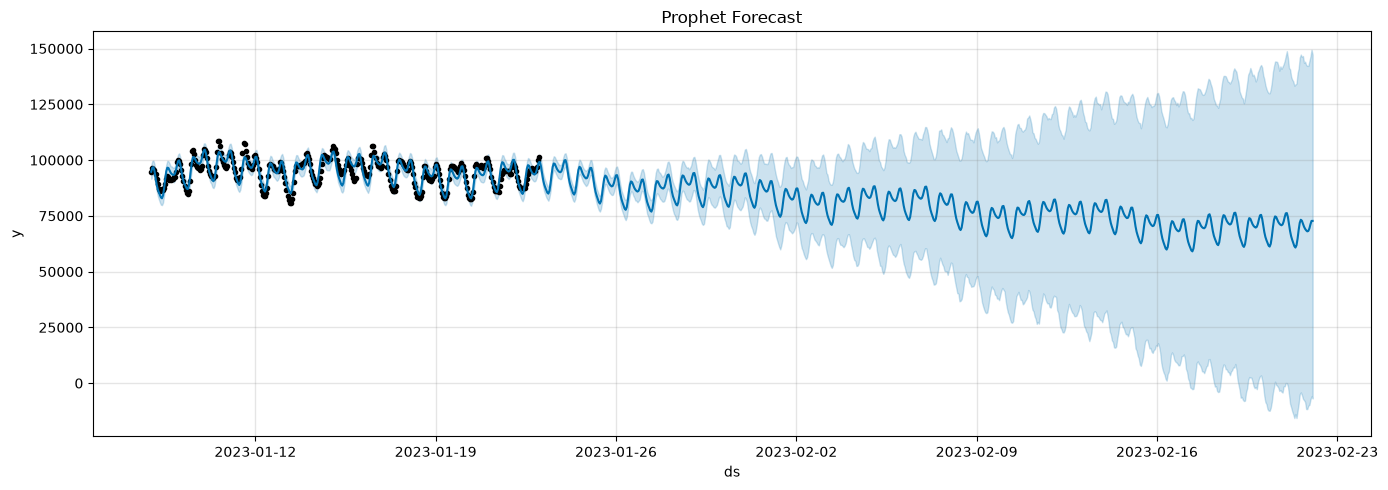

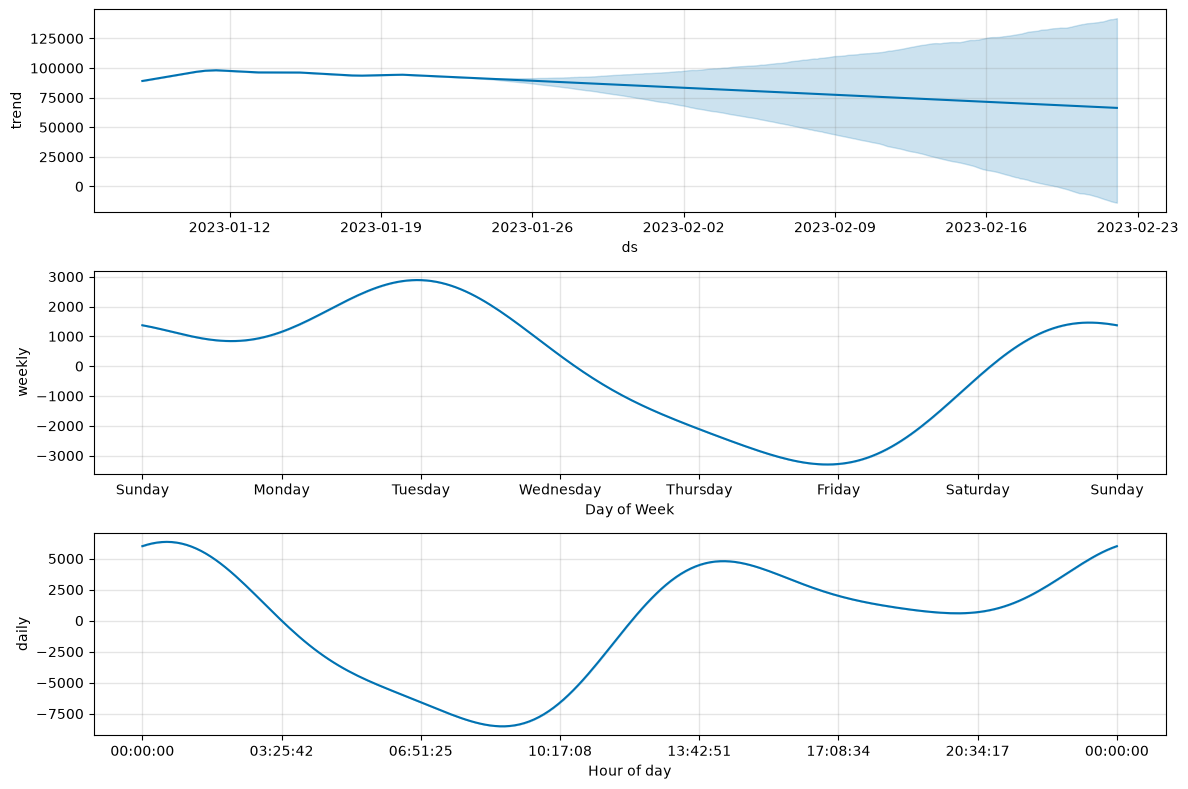

In [45]:
fig1 = model_prophet.plot(forecast)
fig1.set_size_inches(14, 5)
plt.title("Prophet Forecast")
plt.tight_layout()
plt.show()

fig2 = model_prophet.plot_components(forecast)
fig2.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

## 4.5 Model 2 · SARIMA

SARIMA(1,1,1)×(1,1,1,24) — demonstrates classical statistical rigour. Fit once on training data and forecast the entire test horizon in one shot (batch forecast, not rolling, for speed).

In [46]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

train_series = train.set_index("timestamp")["D"]
test_series  = test.set_index("timestamp")["D"]

t0 = time.time()
sarima_model = SARIMAX(
    train_series,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)
sarima_time = time.time() - t0
print(f"SARIMA training time: {sarima_time:.1f}s")

sarima_forecast = sarima_fit.forecast(steps=len(test_series))
sarima_preds  = sarima_forecast.values
sarima_actual = test_series.values

print(f"SARIMA  RMSE={rmse(sarima_actual, sarima_preds):.1f}  MAPE={mape(sarima_actual, sarima_preds):.2f}%  MAE={mae(sarima_actual, sarima_preds):.1f}")

c:\Users\EBOUTIK\miniconda3\envs\energy\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\EBOUTIK\miniconda3\envs\energy\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


SARIMA training time: 9.4s
SARIMA  RMSE=23451.6  MAPE=21.38%  MAE=18886.9


## 4.6 Model 3 · XGBoost + lag features + SHAP

XGBoost with lag features (1 h, 24 h, 168 h) represents the ML approach.  
SHAP values explain *which lags drive each prediction* — a strong talking point with employers.

In [47]:
import xgboost as xgb
import shap

df_ml = df.copy()
df_ml["lag_1h"]   = df_ml["D"].shift(1)
df_ml["lag_24h"]  = df_ml["D"].shift(24)
df_ml["lag_168h"] = df_ml["D"].shift(168)
df_ml = df_ml.dropna().reset_index(drop=True)

train_ml = df_ml[df_ml["timestamp"] < CUTOFF]
test_ml  = df_ml[df_ml["timestamp"] >= CUTOFF]

FEATURES = ["lag_1h", "lag_24h", "lag_168h", "hour", "dayofweek", "month",
            "is_weekend", "season", "hour_sin", "hour_cos", "rolling_7d_avg"]

X_train, y_train = train_ml[FEATURES], train_ml["D"]
X_test,  y_test  = test_ml[FEATURES],  test_ml["D"]

t0 = time.time()
xgb_model = xgb.XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)],
              verbose=False)
xgb_time = time.time() - t0

xgb_preds  = xgb_model.predict(X_test)
xgb_actual = y_test.values

print(f"XGBoost training time: {xgb_time:.1f}s")
print(f"XGBoost  RMSE={rmse(xgb_actual, xgb_preds):.1f}  MAPE={mape(xgb_actual, xgb_preds):.2f}%  MAE={mae(xgb_actual, xgb_preds):.1f}")

xgb_forecast_df = pd.DataFrame({
    'timestamp': test_ml['timestamp'].values, 
    'actual_mw': xgb_actual,
    'xgb_forecast_mw': xgb_preds
})


xgb_forecast_df['abs_error'] = abs(xgb_forecast_df['actual_mw'] - xgb_forecast_df['xgb_forecast_mw'])
xgb_forecast_df['ape'] = (xgb_forecast_df['abs_error'] / xgb_forecast_df['actual_mw']) * 100


xgb_forecast_df.to_csv('../dashboard/xgboost_forecast.csv', index=False)

print(f"Saved {len(xgb_forecast_df)} forecast rows to 'xgboost_forecast.csv'")
print(xgb_forecast_df.head())

XGBoost training time: 0.8s
XGBoost  RMSE=3986.8  MAPE=3.11%  MAE=2896.8
Saved 721 forecast rows to 'xgboost_forecast.csv'
            timestamp  actual_mw  xgb_forecast_mw    abs_error       ape
0 2023-01-23 01:00:00    99736.0    100557.921875   821.921875  0.824097
1 2023-01-23 02:00:00    97854.0     97593.953125   260.046875  0.265750
2 2023-01-23 03:00:00    94787.0     95941.296875  1154.296875  1.217780
3 2023-01-23 04:00:00    91627.0     92254.328125   627.328125  0.684654
4 2023-01-23 05:00:00    89367.0     90046.968750   679.968750  0.760872


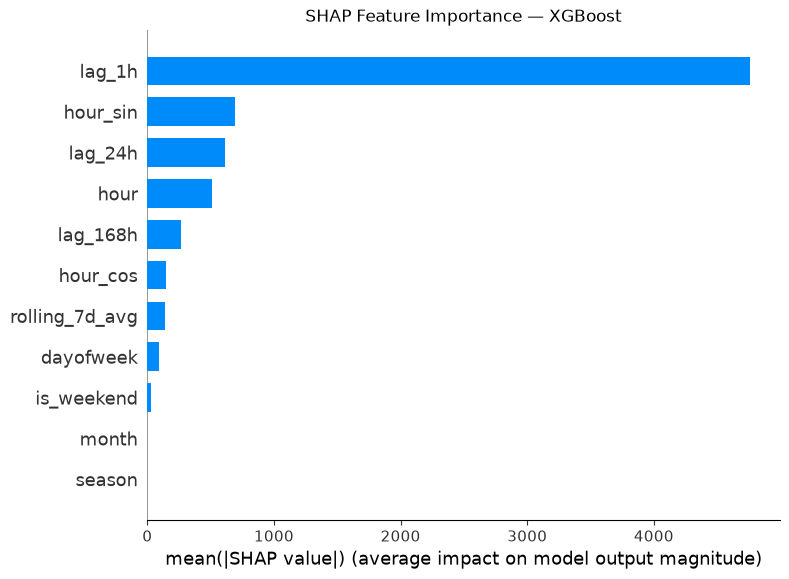

Saved 07_shap_importance.png


In [48]:
# SHAP feature importance
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance — XGBoost")
plt.tight_layout()
plt.savefig("../reports/figures/07_shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 07_shap_importance.png")

## 4.7 EIA day-ahead benchmark

In [49]:
eia_actual = df["D"].values
eia_forecast = df["DF"].values
eia_mape_val = mape(eia_actual, eia_forecast)
eia_rmse_val = rmse(eia_actual, eia_forecast)
eia_mae_val  = mae(eia_actual, eia_forecast)
print(f"EIA Benchmark  RMSE={eia_rmse_val:.1f}  MAPE={eia_mape_val:.2f}%  MAE={eia_mae_val:.1f}")

EIA Benchmark  RMSE=3435.6  MAPE=3.02%  MAE=2808.4


## 4.8 Model comparison table

In [50]:
results = pd.DataFrame([
    {"Model": "Prophet",          "RMSE": rmse(prophet_actual, prophet_preds), "MAPE (%)": mape(prophet_actual, prophet_preds), "MAE": mae(prophet_actual, prophet_preds), "Train time (s)": prophet_time},
    {"Model": "SARIMA",           "RMSE": rmse(sarima_actual,  sarima_preds),  "MAPE (%)": mape(sarima_actual,  sarima_preds),  "MAE": mae(sarima_actual,  sarima_preds),  "Train time (s)": sarima_time},
    {"Model": "XGBoost",          "RMSE": rmse(xgb_actual,    xgb_preds),    "MAPE (%)": mape(xgb_actual,    xgb_preds),    "MAE": mae(xgb_actual,    xgb_preds),    "Train time (s)": xgb_time},
    {"Model": "EIA Forecast (DF)","RMSE": eia_rmse_val,                        "MAPE (%)": eia_mape_val,                        "MAE": eia_mae_val,                        "Train time (s)": None},
])

for c in ["RMSE","MAE"]:
    results[c] = results[c].round(1)
results["MAPE (%)"] = results["MAPE (%)"].round(3)

results.to_csv("../reports/model_comparison.csv", index=False)
print("Saved model_comparison.csv")

results.style \
    .highlight_min(subset=["RMSE","MAPE (%)","MAE"], color="lightgreen") \
    .format({"RMSE": "{:,.1f}", "MAE": "{:,.1f}", "MAPE (%)": "{:.3f}", "Train time (s)": lambda x: f"{x:.1f}" if pd.notna(x) else "—"})

Saved model_comparison.csv


,Model,RMSE,MAPE (%),MAE,Train time (s)
0,Prophet,"16,025.8",15.253,"14,403.9",0.3
1,SARIMA,"23,451.6",21.382,"18,886.9",9.4
2,XGBoost,"3,986.8",3.111,"2,896.8",0.8
3,EIA Forecast (DF),"3,435.6",3.016,"2,808.4",—


## 4.9 Actual vs Predicted — 30-day test period

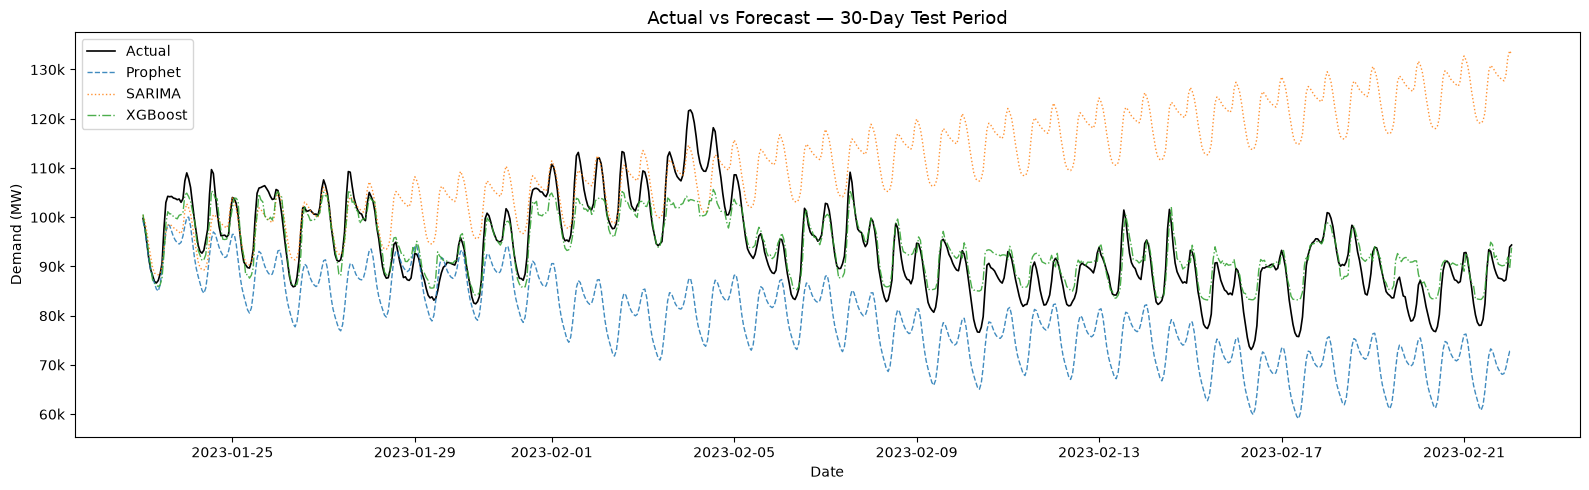

Saved 08_forecast_vs_actual.png


In [51]:
fig, ax = plt.subplots(figsize=(16, 5))
test_ts = test.set_index("timestamp")["D"]
ax.plot(test_ts.index, test_ts.values, label="Actual", linewidth=1.2, color="black")
ax.plot(test_ts.index, prophet_preds, label="Prophet", linewidth=1, linestyle="--", alpha=0.85)
ax.plot(test_ts.index, sarima_preds,  label="SARIMA",  linewidth=1, linestyle=":",  alpha=0.85)
ax.plot(test_ml["timestamp"].values, xgb_preds, label="XGBoost", linewidth=1, linestyle="-.", alpha=0.85)
ax.set_title("Actual vs Forecast — 30-Day Test Period", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Demand (MW)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.legend()
plt.tight_layout()
fig.savefig("../reports/figures/08_forecast_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 08_forecast_vs_actual.png")

## 4.10 Save models

In [52]:
with open("../models/prophet_model.pkl", "wb") as f:
    pickle.dump(model_prophet, f)

xgb_model.save_model("../models/xgboost_model.json")

with open("../models/sarima_fit.pkl", "wb") as f:
    pickle.dump(sarima_fit, f)

print("Models saved:")
print("  models/prophet_model.pkl")
print("  models/xgboost_model.json")
print("  models/sarima_fit.pkl")

results.to_excel("../dashboard/model_comparison.xlsx", index=False)

Models saved:
  models/prophet_model.pkl
  models/xgboost_model.json
  models/sarima_fit.pkl
